## K Nearest Neighbour Classifier

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# %matplotlib inline

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, # 1000 observations 
    n_features=3, # 3 total features
     n_redundant=1,
    n_classes=2, # binary target/label 
    random_state=999 
)

In [8]:
pd.DataFrame(X).isnull().sum()
pd.DataFrame(y).isnull().sum()

0    0
dtype: int64

In [3]:
X, y

(array([[-0.33504974,  0.02852654,  1.16193084],
        [-1.37746253, -0.4058213 ,  0.44359618],
        [-1.04520026, -0.72334759, -3.10470423],
        ...,
        [-0.75602574, -0.51816111, -2.20382324],
        [ 0.56066316, -0.07335845, -2.15660348],
        [-1.87521902, -1.11380394, -4.04620773]]),
 array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0,
        0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
        0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
        0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
        0, 1, 1, 1, 1, 1,

In [9]:
from sklearn.decomposition import PCA

Text(0, 0.5, 'Axis 2')

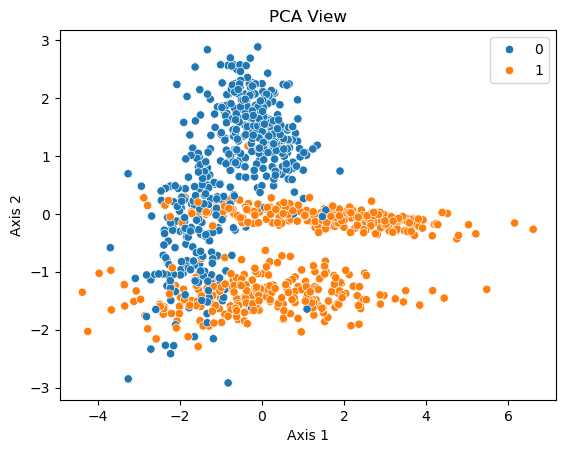

In [18]:
pc = PCA(n_components= 2)

plt.clf()
sns.scatterplot(x = pc.fit_transform(X)[:,0], y = pc.fit_transform(X)[:,1], hue = y)
plt.title("PCA View")
plt.xlabel('Axis 1')
plt.ylabel('Axis 2')

In [21]:
pd.DataFrame(X).describe()

,0,1,2
count,1000.000000,1000.000000,1000.000000
mean,0.001324,-0.000522,-0.007985
std,1.346097,0.522960,1.427861
min,-2.894206,-1.113804,-4.426408
25%,-1.032345,-0.389049,-1.145308
50%,-0.268182,-0.132162,0.216951
75%,0.998166,0.329133,1.091117
max,4.445713,2.021670,4.465644


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [28]:
from sklearn.neighbors import KNeighborsClassifier

In [29]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [30]:
classifier=KNeighborsClassifier(n_neighbors=5,algorithm='auto')
classifier.fit(X_train,y_train)

KNeighborsClassifier()

In [33]:
from sklearn import metrics as m 

In [34]:
##Performance
y_pred=classifier.predict(X_test)

print("Accuracy Score: ",round(m.accuracy_score(y_pred,y_test),3))
print("Precision Score: ",round(m.precision_score(y_pred,y_test),3))
print("Recall Score: ",round(m.recall_score(y_pred,y_test),3))
print("F1 Score: ",round(m.f1_score(y_pred,y_test),3))

Accuracy Score:  0.906
Precision Score:  0.876
Recall Score:  0.928
F1 Score:  0.901


## Tuning

In [51]:
Knn= KNeighborsClassifier()
param_grid = {
    'n_neighbors': list(range(1,31)), 
    'weights': ['uniform', 'distance'],
    'algorithm':['auto'], 
    'p': list(range(1,6)),
    # 'metric': ['minkowski']
}

In [52]:
gv_knn = GridSearchCV(Knn, param_grid= param_grid, n_jobs=-1, cv = 5, scoring= 'accuracy')

In [53]:
gv_knn.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['auto'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30],
                         'p': [1, 2, 3, 4, 5],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [55]:
gv_knn.best_params_

{'algorithm': 'auto', 'n_neighbors': 9, 'p': 2, 'weights': 'uniform'}

In [56]:
y_pred1=gv_knn.predict(X_test)

print("Accuracy Score: ",round(m.accuracy_score(y_pred1,y_test),3))
print("Precision Score: ",round(m.precision_score(y_pred1,y_test),3))
print("Recall Score: ",round(m.recall_score(y_pred1,y_test),3))
print("F1 Score: ",round(m.f1_score(y_pred1,y_test),3))

Accuracy Score:  0.912
Precision Score:  0.901
Recall Score:  0.918
F1 Score:  0.909


In [58]:
print(m.classification_report(y_pred1,y_test))

              precision    recall  f1-score   support

           0       0.92      0.91      0.91       172
           1       0.90      0.92      0.91       158

    accuracy                           0.91       330
   macro avg       0.91      0.91      0.91       330
weighted avg       0.91      0.91      0.91       330

